In [1]:
import os # Configure which GPU 
# if os.getenv("CUDA_VISIBLE_DEVICES") is None:
#     gpu_num = 0 # Use "" to use the CPU
#     os.environ["CUDA_VISIBLE_DEVICES"] = f"{gpu_num}"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = ''

# Import or install Sionna
try:
    import sionna.phy
    import sionna.rt
except ImportError as e:
    import sys

# Configure the notebook to use only a single GPU and allocate only as much memory as needed
# For more details, see https://www.tensorflow.org/guide/gpu
import tensorflow as tf
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        tf.config.experimental.set_memory_growth(gpus[0], True)
    except RuntimeError as e:
        print(e) 

# Avoid warnings from TensorFlow
tf.get_logger().setLevel('ERROR')

import numpy as np

# For link-level simulations
from sionna.phy.channel import OFDMChannel, CIRDataset
from sionna.phy.nr import PUSCHConfig, PUSCHTransmitter, PUSCHReceiver
from sionna.phy.utils import ebnodb2no, PlotBER
from sionna.phy.ofdm import KBestDetector, LinearDetector
from sionna.phy.mimo import StreamManagement

# Import Sionna RT components
from sionna.rt import load_scene, Camera, Transmitter, Receiver, PlanarArray,\
                      PathSolver, RadioMapSolver

no_preview = True # Toggle to False to use the preview widget
                  # instead of rendering for scene visualization

import matplotlib.pyplot as plt
from numpy.fft import fft, fftshift, fftfreq

2025-04-26 09:49:59.731772: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-26 09:49:59.754173: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-26 09:49:59.754191: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-26 09:49:59.755013: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-26 09:49:59.759372: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# --------------------------------------------------------------------
# helper: return min / max delay (in seconds) seen in 'paths'
# --------------------------------------------------------------------
def delay_bounds(paths_obj):
    # paths_obj.tau shape: (batch, rx, rx_ant, tx, tx_ant, paths)
    tau = paths_obj.tau.numpy().squeeze()   # drop singleton axes
    tau = tau[np.isfinite(tau)]             # remove padded inf
    return float(np.min(tau)), float(np.max(tau))

# --------------------------------------------------------------------
# helper: build taps with an automatically chosen resolution / window
# --------------------------------------------------------------------
def taps_auto(paths_obj, nr_samples=2048, oversample=4):
    t_min, t_max = delay_bounds(paths_obj)
    span = (t_max - t_min) if t_max > t_min else 1e-6          # ≥ 1 µs
    dt   = span / nr_samples / oversample                      # finer grid
    taps = paths_obj.taps(
        bandwidth = 1.0 / dt,
        l_min     = 0,
        l_max     = nr_samples - 1,
        normalize = False,
        normalize_delays = True,
        out_type  = "tf"
    )
    return taps.numpy().squeeze(), dt                          # (Tx, taps)

def add_safe(device):
    try:
        scene.add(device)
    except ValueError:
        pass

def run_solver():
    return solver(
        scene,
        max_depth=6,
        los=True,
        specular_reflection=True,
        diffuse_reflection=False,
        refraction=True
    )

2025-04-26 09:50:01.134115: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-26 09:50:01.134202: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-04-26 09:50:01.134243: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-

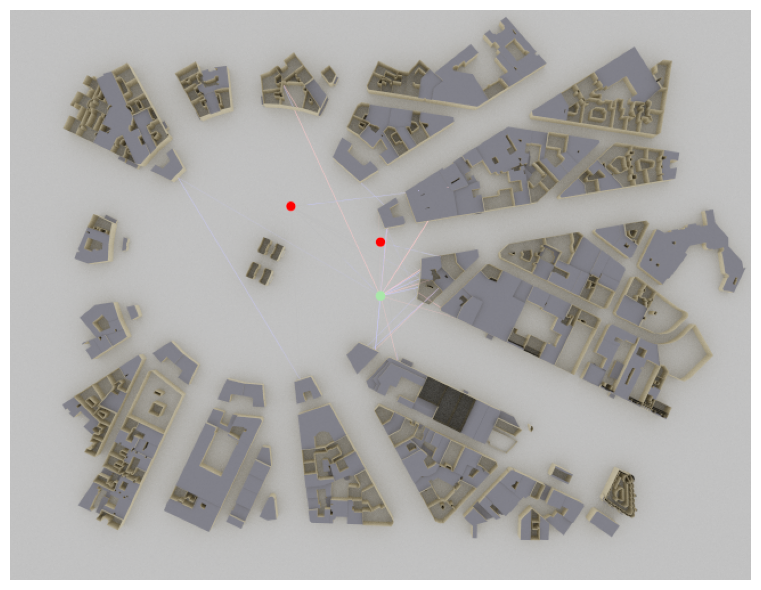

In [3]:
# ====================================================================
# Sionna RT – One-cell demo: 5 visualisations of interference effects
# 1 Constellation  2 PDP  3 |H(f)|  4 SINR hist  5 SER-vs-JNR curve
# Tested: Python 3.11 · TensorFlow 2.19 · Sionna 1.0.2 · Matplotlib 3.3
# ====================================================================

# -------------------------- 1) Scene & arrays -----------------------
# scene = load_scene()
scene = load_scene(sionna.rt.scene.etoile)
# scene = load_scene(sionna.rt.scene.munich)
iso = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
scene.tx_array = scene.tx_array or iso
scene.rx_array = scene.rx_array or iso

tx_main = Transmitter("tx_main", position=[0, 60, 2.0] ); add_safe(tx_main);
tx_i = Transmitter("tx_i", position=[-100, 100, 2.0] ); add_safe(tx_i);
rx = Receiver   ("rx", position=[0, 0, 1.5]); add_safe(rx);

# # scene.munich
# tx_main = Transmitter("tx_main", position=[0, 100, 2.0]); add_safe(tx_main);
# tx_i = Transmitter("tx_i", position=[150, 170, 2.0]); add_safe(tx_i);
# rx = Receiver   ("rx", position=[200, 200, 1.5]); add_safe(rx);

tx_main.look_at(rx);  # Transmitter points towards receiver
tx_i.look_at(rx);

# ------------------ 2) Path-finding (+ auto relocate interferer) ----
solver = PathSolver()

paths = run_solver()
h_np  = paths.taps(20e6, 0, 0, normalize=False,
                   normalize_delays=True, out_type="tf").numpy().squeeze()

if h_np.shape[0] < 2:                                     # only main Tx hit
    offsets = [(-5, 0), (5, 5), (-5, 5), (0, -5), (5, -5)]
    for ox, oy in offsets:
        tx_i.position = [rx.position[0] + ox, rx.position[1] + oy, 2.0]
        tx_i.look_at(rx)
        paths = run_solver()
        h_np = paths.taps(20e6, 0, 0,
                          normalize=False, normalize_delays=True,
                          out_type="tf").numpy().squeeze()
        if h_np.shape[0] > 1:
            break                                           # interferer OK

h_main = h_np[0]
h_int  = h_np[1] if h_np.shape[0] > 1 else 0.0




# -------------------------- 3) Baseband signals ---------------------
N_SYM = 4096
bits  = np.random.randint(0, 2, (N_SYM, 2))
x     = (1 - 2*bits[:, 0] + 1j * (1 - 2*bits[:, 1])) / np.sqrt(2)

y_sig_raw = h_main * x
y_int_raw = h_int  * x

JNR_dB = 10.0
scale  = 0.0 if h_int == 0 else np.sqrt(
    np.mean(np.abs(y_sig_raw)**2) /
    np.mean(np.abs(y_int_raw)**2) / 10**(JNR_dB / 10)
)
y_int  = y_int_raw * scale
# y_int  = y_int_raw


EbNo_dB = 10.0
N0      = np.mean(np.abs(y_sig_raw)**2) / (10**(EbNo_dB / 10) * 2)
noise   = np.sqrt(N0 / 2) * (np.random.randn(N_SYM) + 1j*np.random.randn(N_SYM))

y_no_i   = y_sig_raw + noise
y_with_i = y_sig_raw + y_int + noise

y_eq_no_i   = y_no_i   / h_main
y_eq_with_i = y_with_i / h_main

# --- 顯示場景預覽圖 (預設) ---
# scene.preview()

# # scene.munich
# my_cam = Camera(position=[0,0,2000], look_at=[0,2,0])
# scene.render(camera=my_cam, paths=paths, clip_at=20);

my_cam = Camera(position=[0,0,1000], look_at=[0,1,0])
scene.render(camera=my_cam, resolution=[650, 500], num_samples=512, paths=paths, clip_at=20); # Increase num_samples to increase image quality


plt.show()

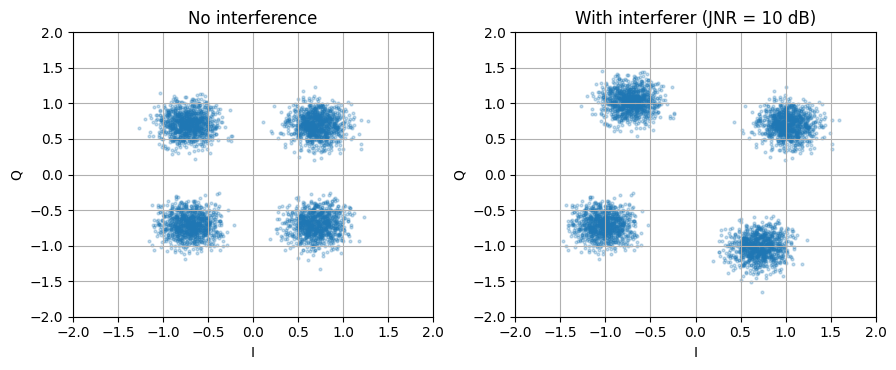

In [4]:
# -------------------------- 4) Plot 1 – constellation ---------------
fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
ax[0].scatter(y_eq_no_i.real,   y_eq_no_i.imag,   s=4, alpha=.25)

ax[1].scatter(y_eq_with_i.real, y_eq_with_i.imag, s=4, alpha=.25)
ax[0].set(title="No interference", xlabel="I", ylabel="Q",xlim = [-2 , 2] ,ylim = [-2 , 2]); ax[0].grid(True)
ttl = "With interferer (JNR = 10 dB)" if h_int != 0 else "Interferer absent"
ax[1].set(title=ttl, xlabel="I", ylabel="Q",xlim = [-2 , 2] ,ylim = [-2 , 2]);               ax[1].grid(True)
plt.tight_layout(); plt.show()

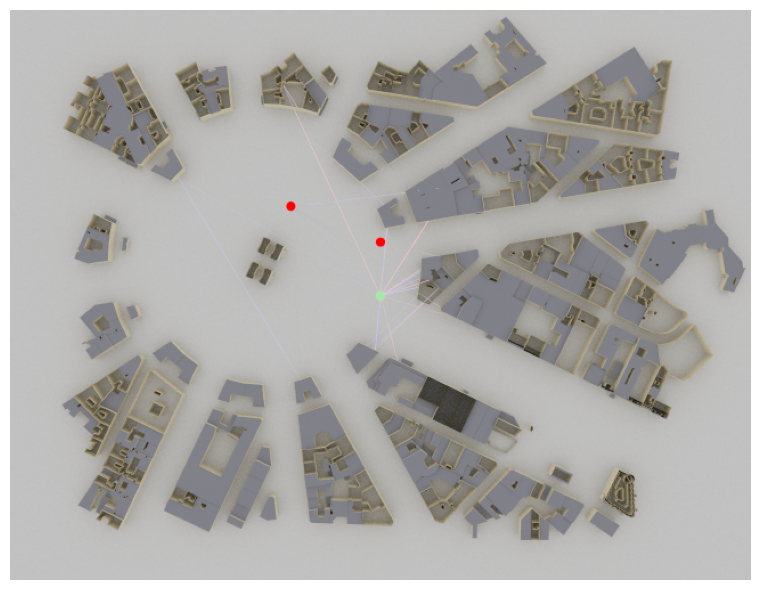

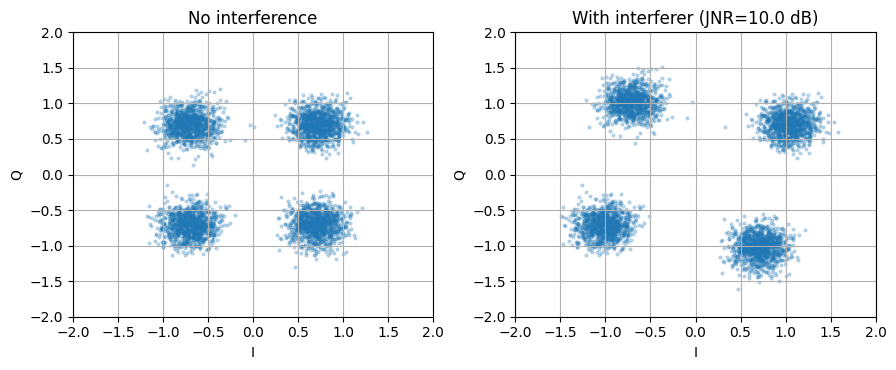

In [5]:
"""
One-cell interference demo – tested with:
  • Python 3.11
  • TensorFlow 2.19
  • Sionna 1.0.2 (meta-package: RT + PHY + SYS)
"""

# --------------------------------------------------------------------#
# 0) Imports & GPU housekeeping
# --------------------------------------------------------------------#
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"        # silence TF

try:
    import sionna, sionna.rt, sionna.phy
except ImportError:
    os.system("pip install --quiet --upgrade sionna")  # installs RT+PHY+SYS
    import sionna, sionna.rt, sionna.phy

import tensorflow as tf
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft, fftshift, fftfreq

# RT helpers
from sionna.rt import (
    load_scene, PlanarArray, Transmitter, Receiver, Camera,
    PathSolver, RadioMapSolver, subcarrier_frequencies
)

# PHY helpers (unchanged in 1.0.2)
from sionna.phy.channel import OFDMChannel, CIRDataset
from sionna.phy.nr import PUSCHConfig, PUSCHTransmitter, PUSCHReceiver
from sionna.phy.utils import ebnodb2no, PlotBER
from sionna.phy.ofdm import KBestDetector, LinearDetector
from sionna.phy.mimo import StreamManagement

# --------------------------------------------------------------------#
# 1) Helper utilities (unchanged)
# --------------------------------------------------------------------#
def delay_bounds(paths):
    tau = paths.tau.numpy().squeeze()
    tau = tau[np.isfinite(tau)]
    return float(np.min(tau)), float(np.max(tau))

def taps_auto(paths, nr_samples=2048, oversample=4):
    t_min, t_max = delay_bounds(paths)
    span = (t_max - t_min) if t_max > t_min else 1e-6
    dt   = span / nr_samples / oversample
    taps = paths.taps(
        bandwidth=1.0 / dt,
        l_min=0, l_max=nr_samples-1,
        normalize=False, normalize_delays=True,
        out_type="tf"
    )
    return taps.numpy().squeeze(), dt

def add_safe(dev):                                 # idempotent add
    try: scene.add(dev)
    except ValueError: pass

# Path solver wrapper
_solver = PathSolver()
def run_solver():
    return _solver(
        scene,
        max_depth=6, los=True,
        specular_reflection=True,
        diffuse_reflection=False,
        refraction=True
    )

# --------------------------------------------------------------------#
# 2) Scene definition
# --------------------------------------------------------------------#
scene = load_scene(sionna.rt.scene.etoile)  # or .munich
iso   = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
scene.tx_array = scene.tx_array or iso
scene.rx_array = scene.rx_array or iso

tx_main = Transmitter("tx_main", position=[0, 60, 2.0]);  add_safe(tx_main)
tx_intf = Transmitter("tx_i",   position=[-100, 100, 2.0]); add_safe(tx_intf)
rx      = Receiver   ("rx",     position=[0, 0, 1.5]);     add_safe(rx)

tx_main.look_at(rx)
tx_intf.look_at(rx)

# --------------------------------------------------------------------#
# 3) Ray tracing & basic taps
# --------------------------------------------------------------------#
paths = run_solver()
h_np  = paths.taps(20e6, 0, 0, normalize=False, normalize_delays=True,
                   out_type="tf").numpy().squeeze()

# Auto-relocate interferer if only main Tx arrives
if h_np.shape[0] < 2:
    for ox, oy in [(-5,0), (5,5), (-5,5), (0,-5), (5,-5)]:
        tx_intf.position = [rx.position[0]+ox, rx.position[1]+oy, 2.0]
        tx_intf.look_at(rx)
        h_np = run_solver().taps(20e6, 0, 0,
                                 normalize=False, normalize_delays=True,
                                 out_type="tf").numpy().squeeze()
        if h_np.shape[0] > 1: break

h_main = h_np[0]
h_intf = h_np[1] if h_np.shape[0] > 1 else 0.0

# --------------------------------------------------------------------#
# 4) Baseband QPSK signals with controllable JNR
# --------------------------------------------------------------------#
N  = 4096
bits = np.random.randint(0, 2, (N, 2))
x = (1 - 2*bits[:,0] + 1j*(1 - 2*bits[:,1])) / np.sqrt(2)

y_sig_raw = h_main * x
y_int_raw = h_intf * x

JNR_dB = 10.0
scale  = 0.0 if h_intf == 0 else np.sqrt(
    np.mean(np.abs(y_sig_raw)**2) /
    np.mean(np.abs(y_int_raw)**2) / 10**(JNR_dB/10)
)
y_int = y_int_raw * scale

EbNo_dB = 10.0
N0 = np.mean(np.abs(y_sig_raw)**2) / (10**(EbNo_dB/10) * 2)
noise = np.sqrt(N0/2) * (np.random.randn(N)+1j*np.random.randn(N))

y_no_i   = y_sig_raw + noise
y_with_i = y_sig_raw + y_int + noise

# perfect equalisation
y_eq_no_i   = y_no_i   / h_main
y_eq_with_i = y_with_i / h_main

# --------------------------------------------------------------------#
# 5) Quick rendering of scene & constellation plots
# --------------------------------------------------------------------#
my_cam = Camera(position=[0,0,1000], look_at=[0,1,0])
scene.render(camera=my_cam, resolution=[650,500], num_samples=512,
             paths=paths, clip_at=20)

fig, ax = plt.subplots(1, 2, figsize=(9,3.8))
ax[0].scatter(y_eq_no_i.real,   y_eq_no_i.imag,   s=4, alpha=.25)
ax[1].scatter(y_eq_with_i.real, y_eq_with_i.imag, s=4, alpha=.25)
ax[0].set(title="No interference", xlabel="I", ylabel="Q",
          xlim=[-2,2], ylim=[-2,2]); ax[0].grid(True)
ttl = f"With interferer (JNR={JNR_dB} dB)" if h_intf.any() else "Interferer absent"
ax[1].set(title=ttl, xlabel="I", ylabel="Q",
          xlim=[-2,2], ylim=[-2,2]); ax[1].grid(True)
plt.tight_layout(); plt.show()


Shape of H: (2, 1024)


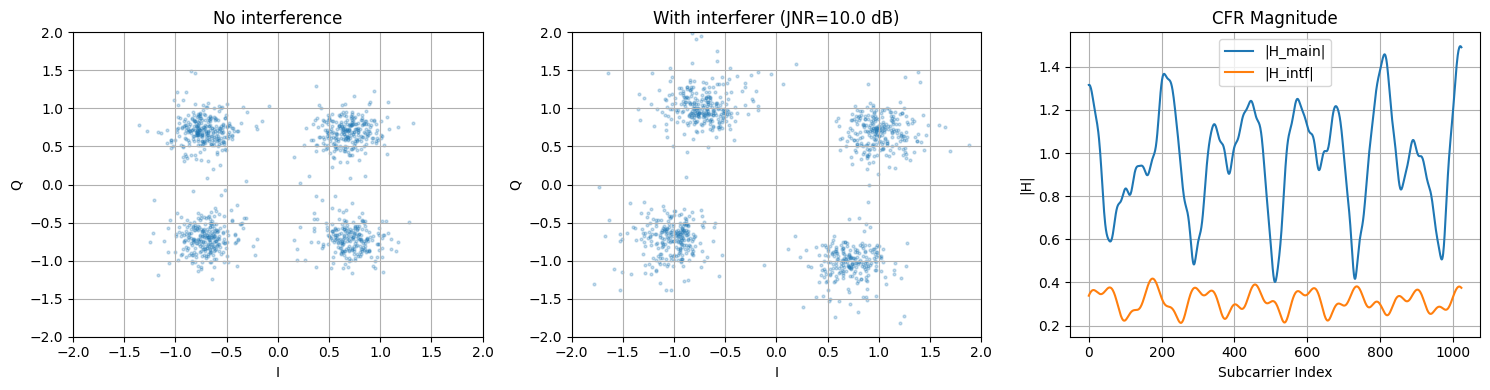

In [6]:
"""
Full-band CFR demo – Python 3.11 · TF 2.19 · Sionna 1.0.2
"""

# --------------------------------------------------------------------#
# 0) Imports & GPU housekeeping
# --------------------------------------------------------------------#
import os, numpy as np, matplotlib.pyplot as plt, tensorflow as tf
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

try:
    import sionna, sionna.rt
except ImportError:
    os.system("pip install -q --upgrade sionna")
    import sionna, sionna.rt

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

from sionna.rt import (
    load_scene, PlanarArray, Transmitter, Receiver,
    Camera, PathSolver, subcarrier_frequencies
)

# --------------------------------------------------------------------#
# 1) Scene & path-solver
# --------------------------------------------------------------------#
scene = load_scene(sionna.rt.scene.etoile)  # or .munich
iso   = PlanarArray(num_rows=1, num_cols=1, pattern="iso", polarization="V")
scene.tx_array = scene.tx_array or iso
scene.rx_array = scene.rx_array or iso

def add_safe(dev):
    try:    scene.add(dev)
    except: pass

tx0 = Transmitter("tx_main", [0, 60, 2]);   add_safe(tx0)
tx1 = Transmitter("tx_i",   [-100,100,2]);  add_safe(tx1)
rx   = Receiver   ("rx",     [0,   0,  1.5]);add_safe(rx)
tx0.look_at(rx); tx1.look_at(rx)

solver = PathSolver()
def solve():
    return solver(scene,
                  max_depth=6, los=True,
                  specular_reflection=True,
                  refraction=True)

# --------------------------------------------------------------------#
# 2) OFDM parameters & CFR
# --------------------------------------------------------------------#
Nsc = 1024         # 子載波數
Δf  = 30e3         # 子載波間隔 30 kHz
fc  = scene.frequency
# 取回所有子載波頻率
freqs = subcarrier_frequencies(Nsc, Δf)

paths = solve()
# 取回 CFR 並 squeeze → shape = (num_tx=2, Nsc)
H = paths.cfr(frequencies=freqs,
              normalize=True,
              normalize_delays=True,
              out_type="numpy").squeeze()
print("Shape of H:", H.shape)  # => (2, 1024)

# 直接用 2 維切片
h_main = H[0, :]              # 主 Tx → Rx
h_intf = H[1, :] if H.shape[0] > 1 else np.zeros(Nsc)

# --------------------------------------------------------------------#
# 3) 生成 QPSK-OFDM 符號
# --------------------------------------------------------------------#
Nsym = 1
bits = np.random.randint(0, 2, (Nsym, Nsc, 2))
X    = (1 - 2*bits[...,0] + 1j*(1-2*bits[...,1]))/np.sqrt(2)  # QPSK

# 直接在頻域作通道作用
Y_sig = X * h_main[np.newaxis, :]
Y_int = X * h_intf[np.newaxis, :]

# JNR & Eb/N0
JNRdB, EbN0dB = 10.0, 10.0
p_sig = np.mean(np.abs(Y_sig)**2)
p_int = np.mean(np.abs(Y_int)**2)
scale = 0.0 if not np.any(h_intf) else np.sqrt(p_sig/p_int/10**(JNRdB/10))
Y_int *= scale
N0    = p_sig/(10**(EbN0dB/10)*2)
noise = np.sqrt(N0/2)*(np.random.randn(*Y_sig.shape)+1j*np.random.randn(*Y_sig.shape))

Y_tot = Y_sig + Y_int + noise

y_no_i   = Y_sig + noise
y_with_i = Y_sig + Y_int + noise

# perfect equalisation
y_eq_no_i   = y_no_i   / h_main
y_eq_with_i = y_with_i / h_main

# --------------------------------------------------------------------#
# 4) 頻域等化 (Zero-Forcing per-subcarrier)
# --------------------------------------------------------------------#
X_hat = Y_tot / h_main[np.newaxis, :]

# --------------------------------------------------------------------#
# 5) 繪圖：中央子載波星座 & CFR 幅度
# --------------------------------------------------------------------#
k = Nsc//2


fig, ax = plt.subplots(1, 3, figsize=(15,4))
ax[0].scatter(y_eq_no_i.real,   y_eq_no_i.imag,   s=4, alpha=.25)
ax[1].scatter(y_eq_with_i.real, y_eq_with_i.imag, s=4, alpha=.25)
ax[0].set(title="No interference", xlabel="I", ylabel="Q",
          xlim=[-2,2], ylim=[-2,2]); ax[0].grid(True)
ttl = f"With interferer (JNR={JNR_dB} dB)" if h_intf.any() else "Interferer absent"
ax[1].set(title=ttl, xlabel="I", ylabel="Q",
          xlim=[-2,2], ylim=[-2,2]); ax[1].grid(True)


# CFR 幅度
ax[2].plot(np.abs(h_main), label="|H_main|")
if np.any(h_intf): ax[2].plot(np.abs(h_intf*scale), label="|H_intf|")
ax[2].set(title="CFR Magnitude", xlabel="Subcarrier Index", ylabel="|H|")
ax[2].grid(True); ax[2].legend()

plt.tight_layout(); plt.show()

# --------------------------------------------------------------------#
# 6) (可選) 場景渲染預覽
# --------------------------------------------------------------------#



In [7]:
rm_solver = RadioMapSolver()
rm = rm_solver(scene,
               max_depth=5,
               cell_size=(1., 1.),
               samples_per_tx=10**7)
scene.preview(  radio_map=rm)

Renderer(camera=PerspectiveCamera(aspect=1.31, children=(DirectionalLight(intensity=0.25, position=(0.0, 0.0, …

(677, 854, 3)


/tmp/ipykernel_3091314/1360573488.py:47: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


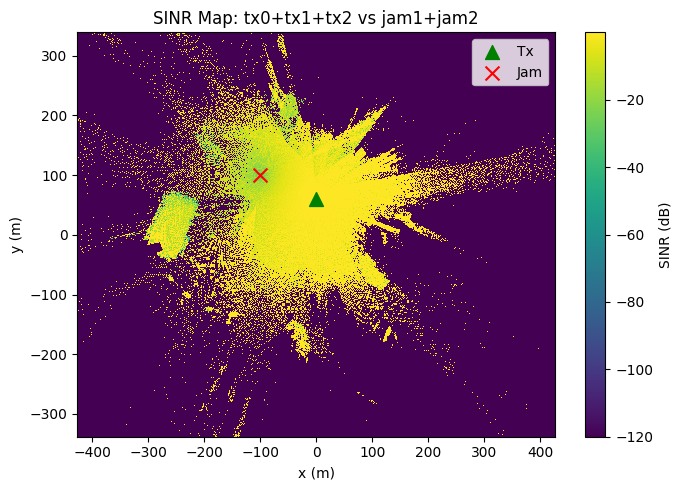

In [8]:
# 1) 获取单元格中心的 x 和 y 坐标
cc       = rm.cell_centers.numpy()    # shape (Ny, Nx, 3)
print(cc.shape)                  # (480, 320, 3)
x_unique = cc[0, :, 0]                # 第一行所有格子中心的 x
y_unique = cc[:, 0, 1]                # 第一列所有格子中心的 y

# 2) 提取前五颗发射机的rss 并转换为 NumPy
rss_list = [rm.rss[i].numpy() for i in range(2)]  # tx0, tx1, tx2
N0 = 1e-12  # 你可以根据实际情况调整

# 3) 计算合并后的 SINR
# rss_list 中分别对应 [tx0, tx1, tx2, jam1, jam2]
rss_desired = rss_list[0]        # tx0+tx1+tx2 的总接收功率
rss_jammer  = rss_list[1]                    # jam1+jam2 的总接收功率



# SINR = desired / (desired + interferers + noise)
sinr = rss_desired / (rss_desired + rss_jammer + N0)

# 如果你想看 dB 形式：
sinr_db = 10 * np.log10(np.clip(sinr, 1e-12, None))


# 4) 绘图
X, Y = np.meshgrid(x_unique, y_unique)
plt.figure(figsize=(7,5))
pcm = plt.pcolormesh(
    X, Y, sinr_db,
    shading='nearest'
)
plt.colorbar(pcm, label="SINR (dB)")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("SINR Map: tx0+tx1+tx2 vs jam1+jam2")
plt.scatter(
    [tx0.position[0]],
    [tx0.position[1]],
    c='g', marker='^', s=100, label='Tx'
)
plt.scatter(
    [tx1.position[0]],
    [tx1.position[1]],
    c='red',   marker='x', s=100, label='Jam'
)
plt.legend()
plt.tight_layout()
plt.show()